https://py-eddy-tracker.readthedocs.io/en/stable/python_module/02_eddy_identification/pet_eddy_detection.html

Using subset of MIOST from: 
<!-- file:// -->
[2025-02-10_SWOT_L4_MIOST_test02.ipynb](/Users/Gomez023/Postdoc/develop/FaSt-SWOT/SWOT/L4_data/MIOST/2025-02-10_SWOT_L4_MIOST_test02.ipynb)

In [2]:
# venv_py_eddy_tracker_05
# venv_py_eddy_tracker_04


In [3]:
from datetime import datetime

from matplotlib import pyplot as plt
from numpy import arange

from py_eddy_tracker import data
from py_eddy_tracker.dataset.grid import RegularGridDataset

import cartopy.crs as ccrs

import numpy as np

from glob import glob
import os

from py_eddy_tracker.observations.observation import EddiesObservations


In [4]:
lon_min_ax, lon_max_ax = -6., 9.
lat_min_ax, lat_max_ax = 35., 45.

def start_axes(title):
    fig = plt.figure(figsize=(13, 5))
    ax = fig.add_axes([0.03, 0.03, 0.90, 0.94])
    ax.set_xlim(lon_min_ax, lon_max_ax), ax.set_ylim(lat_min_ax, lat_max_ax)
    # ax.set_xlim(-6, 36.5), ax.set_ylim(30, 46)
    ax.set_aspect("equal")
    ax.set_title(title, weight="bold")
    return ax


def update_axes(ax, mappable=None):
    ax.grid()
    if mappable:
        plt.colorbar(mappable, cax=ax.figure.add_axes([0.94, 0.05, 0.01, 0.9]))

# Loading MIOST-K v2.0.1:

In [5]:
# indir_duacs_nrt = "/Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/"
# fname = "cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_1741197895707.nc"
# ds_duacs_nrt_apr = xr.open_dataset(indir_duacs_nrt + fname)

indir_miost = "/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/"
outdir = indir_miost + 'subset/'


In [6]:
data_paths_MIOST_v201 = sorted(glob(outdir + "dt_global_allsat_phy_l4_202*_sub.nc"))
data_paths_MIOST_v201

['/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230801_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230802_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230803_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230804_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230805_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230806_sub.nc',
 '/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/

In [7]:
len(data_paths_MIOST_v201)

335

In [8]:
outdir = "/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/"

In [9]:
data_path  = data_paths_MIOST_v201[19]
data_path

'/Users/Gomez023/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/subset/dt_global_allsat_phy_l4_20230820_sub.nc'

In [10]:
a_names_MIOST_v201 = []
c_names_MIOST_v201 = []

for data_path in data_paths_MIOST_v201:
   date = datetime(int(data_path[-15:-11]), int(data_path[-11:-9]),
                    int(data_path[-9:-7]))
   print(date)
   
   a_name = outdir + 'a_MIOST_v2.0.1_' + date.strftime('%Y%m%d')+'.nc'
   c_name = outdir + 'c_MIOST_v2.0.1_' + date.strftime('%Y%m%d')+'.nc'
   
   a_names_MIOST_v201.append(a_name)
   c_names_MIOST_v201.append(c_name)

2023-08-01 00:00:00
2023-08-02 00:00:00
2023-08-03 00:00:00
2023-08-04 00:00:00
2023-08-05 00:00:00
2023-08-06 00:00:00
2023-08-07 00:00:00
2023-08-08 00:00:00
2023-08-09 00:00:00
2023-08-10 00:00:00
2023-08-11 00:00:00
2023-08-12 00:00:00
2023-08-13 00:00:00
2023-08-14 00:00:00
2023-08-15 00:00:00
2023-08-16 00:00:00
2023-08-17 00:00:00
2023-08-18 00:00:00
2023-08-19 00:00:00
2023-08-20 00:00:00
2023-08-21 00:00:00
2023-08-22 00:00:00
2023-08-23 00:00:00
2023-08-24 00:00:00
2023-08-25 00:00:00
2023-08-26 00:00:00
2023-08-27 00:00:00
2023-08-28 00:00:00
2023-08-29 00:00:00
2023-08-30 00:00:00
2023-08-31 00:00:00
2023-09-01 00:00:00
2023-09-02 00:00:00
2023-09-03 00:00:00
2023-09-04 00:00:00
2023-09-05 00:00:00
2023-09-06 00:00:00
2023-09-07 00:00:00
2023-09-08 00:00:00
2023-09-09 00:00:00
2023-09-10 00:00:00
2023-09-11 00:00:00
2023-09-12 00:00:00
2023-09-13 00:00:00
2023-09-14 00:00:00
2023-09-15 00:00:00
2023-09-16 00:00:00
2023-09-17 00:00:00
2023-09-18 00:00:00
2023-09-19 00:00:00


In [11]:
a_names_MIOST_v201

['/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230801.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230802.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230803.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230804.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230805.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230806.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230807.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230808.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230809.nc',
 '/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_MIOST_v2.0.1_20230810.nc',
 '/Users/Gomez023/Ne

## Loading all eddies into same object:
https://py-eddy-tracker.readthedocs.io/en/stable/python_module/02_eddy_identification/pet_statistics_on_identification.html

In [12]:
nb_a_m_v201 = []
for ff in a_names_MIOST_v201[0:-30]:
    ff_l = EddiesObservations.load_file(ff)
    nb_a_m_v201.append(ff_l.shape[0])
nb_a_m_v201 = np.array(nb_a_m_v201)

File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but softwa

In [13]:
nb_a_m_v201

array([18, 18, 17, 17, 17, 17, 15, 15, 15, 17, 18, 19, 17, 16, 17, 17, 20,
       18, 19, 20, 20, 21, 21, 21, 21, 21, 19, 21, 18, 18, 19, 20, 17, 18,
       17, 16, 15, 16, 17, 16, 17, 17, 17, 15, 16, 16, 17, 15, 17, 17, 19,
       18, 21, 21, 23, 20, 20, 19, 19, 21, 19, 19, 17, 15, 19, 19, 20, 19,
       17, 19, 18, 20, 20, 20, 19, 20, 19, 21, 20, 20, 19, 20, 18, 19, 19,
       20, 21, 18, 18, 17, 16, 20, 20, 18, 20, 18, 19, 20, 19, 20, 18, 18,
       17, 16, 18, 19, 18, 18, 19, 19, 20, 19, 19, 19, 17, 16, 16, 15, 17,
       17, 17, 17, 17, 17, 18, 21, 19, 18, 17, 18, 21, 21, 20, 18, 18, 18,
       17, 16, 19, 20, 20, 22, 22, 22, 22, 22, 23, 21, 21, 19, 17, 16, 16,
       15, 17, 18, 19, 19, 20, 20, 21, 22, 20, 21, 23, 22, 21, 21, 20, 19,
       18, 19, 19, 19, 21, 18, 16, 15, 18, 19, 18, 18, 16, 17, 18, 17, 19,
       18, 17, 18, 17, 16, 19, 20, 18, 19, 19, 19, 19, 20, 20, 20, 21, 19,
       20, 20, 19, 18, 20, 21, 21, 22, 21, 22, 23, 21, 23, 22, 23, 23, 21,
       22, 19, 20, 20, 20

In [14]:
len(nb_a_m_v201)

305

In [15]:
nb_c_m_v201 = []
for ff in c_names_MIOST_v201[0:-30]:
    ff_l = EddiesObservations.load_file(ff)
    nb_c_m_v201.append(ff_l.shape[0])
nb_c_m_v201 = np.array(nb_c_m_v201)

File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but softwa

In [16]:
nb_c_m_v201

array([18, 15, 17, 18, 18, 17, 18, 18, 19, 17, 18, 20, 22, 21, 23, 26, 24,
       25, 24, 21, 21, 20, 19, 19, 20, 22, 25, 21, 25, 23, 23, 21, 20, 21,
       22, 22, 22, 20, 18, 16, 17, 19, 19, 18, 17, 15, 18, 16, 16, 15, 16,
       17, 16, 18, 18, 18, 19, 20, 18, 19, 19, 18, 18, 21, 22, 21, 20, 21,
       19, 21, 20, 23, 22, 21, 20, 20, 20, 22, 18, 18, 16, 14, 16, 18, 19,
       17, 20, 20, 19, 19, 21, 17, 19, 18, 15, 17, 17, 16, 17, 17, 16, 21,
       22, 23, 25, 27, 24, 20, 18, 21, 18, 22, 19, 21, 22, 23, 23, 25, 22,
       26, 24, 22, 22, 22, 21, 21, 18, 19, 18, 17, 18, 21, 21, 21, 19, 21,
       21, 23, 21, 21, 21, 24, 23, 21, 21, 23, 22, 24, 25, 24, 24, 24, 22,
       18, 17, 16, 19, 17, 17, 19, 19, 20, 15, 16, 16, 15, 19, 19, 20, 16,
       17, 18, 20, 20, 19, 19, 19, 18, 18, 18, 21, 20, 22, 17, 15, 14, 17,
       16, 15, 18, 18, 20, 19, 22, 20, 18, 15, 16, 20, 19, 21, 20, 20, 19,
       18, 16, 20, 18, 18, 18, 17, 17, 17, 18, 19, 21, 20, 19, 20, 21, 20,
       22, 23, 21, 21, 22

In [17]:
nb_c_m_v201.sum()

6217

## Load DUACS-NRT:

In [18]:
indir_duacs_nrt = "/Users/Gomez023/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/"

data_paths_DUACS_NRT = sorted(glob(indir_duacs_nrt + "wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_202*_sub.nc"))

In [19]:
a_names_DUACS_NRT = []
c_names_DUACS_NRT = []

for data_path_DUACS_NRT in data_paths_DUACS_NRT:
   date = datetime(int(data_path_DUACS_NRT[-15:-11]), int(data_path_DUACS_NRT[-11:-9]),
                int(data_path_DUACS_NRT[-9:-7]))
   print(date)
   
   a_name_DUACS_NRT = outdir + 'a_DUACS-NRT_' + date.strftime('%Y%m%d') + '.nc'
   c_name_DUACS_NRT = outdir + 'c_DUACS-NRT_' + date.strftime('%Y%m%d') + '.nc'
   
   a_names_DUACS_NRT.append(a_name_DUACS_NRT)
   c_names_DUACS_NRT.append(c_name_DUACS_NRT)

2023-08-01 00:00:00
2023-08-02 00:00:00
2023-08-03 00:00:00
2023-08-04 00:00:00
2023-08-05 00:00:00
2023-08-06 00:00:00
2023-08-07 00:00:00
2023-08-08 00:00:00
2023-08-09 00:00:00
2023-08-10 00:00:00
2023-08-11 00:00:00
2023-08-12 00:00:00
2023-08-13 00:00:00
2023-08-14 00:00:00
2023-08-15 00:00:00
2023-08-16 00:00:00
2023-08-17 00:00:00
2023-08-18 00:00:00
2023-08-19 00:00:00
2023-08-20 00:00:00
2023-08-21 00:00:00
2023-08-22 00:00:00
2023-08-23 00:00:00
2023-08-24 00:00:00
2023-08-25 00:00:00
2023-08-26 00:00:00
2023-08-27 00:00:00
2023-08-28 00:00:00
2023-08-29 00:00:00
2023-08-30 00:00:00
2023-08-31 00:00:00
2023-09-01 00:00:00
2023-09-02 00:00:00
2023-09-03 00:00:00
2023-09-04 00:00:00
2023-09-05 00:00:00
2023-09-06 00:00:00
2023-09-07 00:00:00
2023-09-08 00:00:00
2023-09-09 00:00:00
2023-09-10 00:00:00
2023-09-11 00:00:00
2023-09-12 00:00:00
2023-09-13 00:00:00
2023-09-14 00:00:00
2023-09-15 00:00:00
2023-09-16 00:00:00
2023-09-17 00:00:00
2023-09-18 00:00:00
2023-09-19 00:00:00


## Loading all eddies into same object:
https://py-eddy-tracker.readthedocs.io/en/stable/python_module/02_eddy_identification/pet_statistics_on_identification.html

In [20]:
a_err_231109 = "/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_DUACS-NRT_20231109.nc"
a_err_231111 = "/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_DUACS-NRT_20231111.nc"

In [21]:
nb_a_d = []
for ff in a_names_DUACS_NRT:
    if (ff == a_err_231109) | (ff == a_err_231111):
        print(ff)
        nb_a_d.append(np.nan)    
    else:
        ff_l = EddiesObservations.load_file(ff)
        nb_a_d.append(ff_l.shape[0])
nb_a_d = np.array(nb_a_d)

File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but softwa

/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_DUACS-NRT_20231109.nc
/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/a_DUACS-NRT_20231111.nc


File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but softwa

In [22]:
nb_a_d

array([13., 12., 13., 11., 11., 11., 10., 11., 11., 12., 12., 11., 11.,
       10.,  8., 10., 12., 11., 15., 11., 11., 12., 12., 15., 14., 14.,
       12., 13., 16., 16., 14., 14., 16., 15., 14., 13., 13., 11., 10.,
       12., 12., 11., 12., 12., 12.,  9., 11., 13., 14., 14., 12., 12.,
       14., 14., 11., 13., 12., 10., 11., 11., 10., 12., 10., 11., 12.,
       13., 13., 13., 12., 15., 14., 16., 17., 15., 16., 14., 16., 11.,
       14., 13., 14., 13., 14., 14., 13., 12., 11.,  9., 10., 11., 10.,
       11., 14., 12., 13., 14., 13., 14., 14., 14., nan, 11., nan, 11.,
       11., 12., 12., 12., 13., 12., 14., 14., 15., 14., 11., 14., 12.,
       10., 13., 13., 15., 14., 13., 14., 13., 11., 11., 12., 12., 13.,
       13., 11., 10., 11., 13., 15., 14., 15., 13., 13., 13., 13., 14.,
       12., 12., 10., 13., 13., 14., 13.,  9., 11., 10., 11., 12., 12.,
       14., 14., 15., 11., 12., 14., 12., 13., 10., 13., 13., 12., 13.,
       12., 11., 12., 10., 11., 10.,  9., 10.,  9., 10., 12.,  9

In [23]:
c_err_231109 = "/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/c_DUACS-NRT_20231109.nc"
c_err_231111 = "/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/c_DUACS-NRT_20231111.nc"

In [24]:
nb_c_d = []
for ff in c_names_DUACS_NRT:
    if (ff == c_err_231109) | (ff == c_err_231111):
        print(ff)
        nb_c_d.append(np.nan)    
    else:
        ff_l = EddiesObservations.load_file(ff)
        nb_c_d.append(ff_l.shape[0])
nb_c_d = np.array(nb_c_d)

File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but softwa

/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/c_DUACS-NRT_20231109.nc
/Users/Gomez023/Nextcloud/Projects/OSR10/Data/outputs/eddy-tracker/c_DUACS-NRT_20231111.nc


File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but software version is '3.6'
File was created with py-eddy-tracker version '0+untagged.753.g8fe5bf1' but softwa

In [25]:
nb_c_d

array([16., 15., 16., 14., 14., 14., 16., 18., 18., 18., 18., 16., 19.,
       17., 16., 19., 17., 18., 18., 18., 14., 19., 23., 19., 18., 16.,
       15., 14., 13., 15., 11., 13., 15., 19., 14., 13., 15., 14., 17.,
       18., 17., 14., 12., 15., 17., 15., 15., 12., 11., 12., 15., 16.,
       15., 13., 15., 13., 17., 14., 13., 15., 14., 16., 16., 14., 17.,
       17., 21., 21., 21., 17., 19., 18., 19., 20., 19., 20., 19., 22.,
       21., 20., 17., 15., 13., 17., 18., 18., 15., 17., 17., 14., 19.,
       16., 16., 15., 18., 16., 18., 20., 18., 14., nan, 19., nan, 20.,
       19., 15., 19., 18., 18., 16., 17., 17., 16., 18., 16., 15., 16.,
       17., 16., 17., 19., 18., 17., 18., 19., 19., 15., 12., 15., 15.,
       14., 16., 17., 19., 20., 17., 14., 15., 19., 19., 20., 21., 22.,
       21., 17., 17., 12., 13., 15., 13., 14., 13., 13., 14., 12., 14.,
       12., 13., 14., 16., 18., 18., 15., 13., 14., 15., 15., 16., 16.,
       12., 13., 13., 15., 13., 15., 12., 13., 15., 17., 15., 15

# Time plots:

In [26]:
from datetime import datetime, timedelta

start_date = datetime.strptime("2023-08-01", "%Y-%m-%d")
end_date = datetime.strptime("2024-05-31", "%Y-%m-%d")
# end_date_mv1 = datetime.strptime("2024-04-30", "%Y-%m-%d")

ndays = (end_date - start_date).days + 1
# ndays_mv1 = (end_date_mv1 - start_date).days + 1

ndates = [start_date + timedelta(days=i) for i in range(ndays)]
print(ndates)

# ndates_mv1 = [start_date + timedelta(days=i) for i in range(ndays_mv1)]

[datetime.datetime(2023, 8, 1, 0, 0), datetime.datetime(2023, 8, 2, 0, 0), datetime.datetime(2023, 8, 3, 0, 0), datetime.datetime(2023, 8, 4, 0, 0), datetime.datetime(2023, 8, 5, 0, 0), datetime.datetime(2023, 8, 6, 0, 0), datetime.datetime(2023, 8, 7, 0, 0), datetime.datetime(2023, 8, 8, 0, 0), datetime.datetime(2023, 8, 9, 0, 0), datetime.datetime(2023, 8, 10, 0, 0), datetime.datetime(2023, 8, 11, 0, 0), datetime.datetime(2023, 8, 12, 0, 0), datetime.datetime(2023, 8, 13, 0, 0), datetime.datetime(2023, 8, 14, 0, 0), datetime.datetime(2023, 8, 15, 0, 0), datetime.datetime(2023, 8, 16, 0, 0), datetime.datetime(2023, 8, 17, 0, 0), datetime.datetime(2023, 8, 18, 0, 0), datetime.datetime(2023, 8, 19, 0, 0), datetime.datetime(2023, 8, 20, 0, 0), datetime.datetime(2023, 8, 21, 0, 0), datetime.datetime(2023, 8, 22, 0, 0), datetime.datetime(2023, 8, 23, 0, 0), datetime.datetime(2023, 8, 24, 0, 0), datetime.datetime(2023, 8, 25, 0, 0), datetime.datetime(2023, 8, 26, 0, 0), datetime.datetime(20

/Users/Gomez023/Postdoc/develop/old_mac_nbs/2017-02-03_TFGlike_stats_clean.ipynb
# --> do???

In [27]:
import matplotlib.dates as mdates


# Separate anticyclones and cyclones:

### Adding dot:

In [28]:
# plt.figure(figsize=(14,7))
# ax1=plt.subplot(211)
# plt.plot(ndates_mv1, nb_a_m_v1, 'C3', linestyle='-', marker='.', label='MIOST-K v1.0.0 anticyc.')
# plt.plot(ndates, nb_a_d, '--.', c='C3', label='DUACS anticyc.')
# plt.grid()
# ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))

# # Optional: Rotate date labels for better readability
# plt.xticks(rotation=45)
# ax1.tick_params(labelbottom=False) # Hide them

# plt.ylabel("Nb. of eddies")
# plt.legend()

# ax1=plt.subplot(212)
# plt.plot(ndates_mv1, nb_c_m_v1, 'C0', linestyle='-', marker='.', label='MIOST-K v1.0.0 cyc.')
# plt.plot(ndates, nb_c_d, '--.', c= 'C0', label='DUACS cyc.')

# plt.grid()
# ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))

# # Optional: Rotate date labels for better readability
# plt.xticks(rotation=45)

# plt.xlabel("Date [DD-MM-YY]")
# plt.ylabel("Nb. of eddies")
# plt.legend()

## Difference:

In [29]:
# plt.figure(figsize=(14,5))
# ax1=plt.subplot(111)
# plt.plot(ndates_mv1, nb_a_m_v1 - nb_a_d[0:121], 'C3', linestyle='-', marker='.', label='MIOST-K v1.0.0 anticyc. - DUACS anticyc.')
# plt.plot(ndates_mv1, nb_c_m_v1 - nb_c_d[0:121], 'C0', linestyle='-', marker='.', label='MIOST-K v1.0.0 cyc. - DUACS cyc.')

# plt.grid()
# ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))

# # Optional: Rotate date labels for better readability
# plt.xticks(rotation=45)

# plt.xlabel("Date [DD-MM-YY]")
# plt.ylabel("Diff. nb. of eddies")
# plt.legend()


# --> interesting that big anticyclone peaks of negative diff, has equivalent high cyclones, maybe one detect some eddies as cyc. and other anticyc??
# Check eddy field for this days!!

## Find days:
Looking for days where negative:

### v.2.0.1

In [30]:
nb_a_m_v201.shape

(305,)

In [31]:
nb_a_d.shape

(305,)

In [32]:
inds_a_v201 = np.where((nb_a_m_v201 - nb_a_d) < 0)[0]
ndates_a_v201 = [ndates[ii] for ii in inds_a_v201]
ndates_a_v201


[]

In [33]:

inds_c_v201 = np.where((nb_c_m_v201 - nb_c_d) < 0)[0]
ndates_c_v201 = [ndates[ii] for ii in inds_c_v201]
ndates_c_v201


[datetime.datetime(2023, 8, 10, 0, 0),
 datetime.datetime(2023, 8, 23, 0, 0),
 datetime.datetime(2023, 9, 9, 0, 0),
 datetime.datetime(2023, 10, 6, 0, 0),
 datetime.datetime(2023, 10, 8, 0, 0),
 datetime.datetime(2023, 10, 18, 0, 0),
 datetime.datetime(2023, 10, 19, 0, 0),
 datetime.datetime(2023, 10, 20, 0, 0),
 datetime.datetime(2023, 10, 21, 0, 0),
 datetime.datetime(2023, 10, 25, 0, 0),
 datetime.datetime(2023, 11, 3, 0, 0),
 datetime.datetime(2023, 11, 5, 0, 0),
 datetime.datetime(2023, 11, 6, 0, 0),
 datetime.datetime(2023, 11, 7, 0, 0),
 datetime.datetime(2023, 12, 13, 0, 0),
 datetime.datetime(2024, 2, 1, 0, 0),
 datetime.datetime(2024, 2, 2, 0, 0),
 datetime.datetime(2024, 2, 3, 0, 0),
 datetime.datetime(2024, 2, 4, 0, 0),
 datetime.datetime(2024, 2, 5, 0, 0),
 datetime.datetime(2024, 2, 7, 0, 0),
 datetime.datetime(2024, 2, 20, 0, 0),
 datetime.datetime(2024, 2, 24, 0, 0),
 datetime.datetime(2024, 2, 25, 0, 0),
 datetime.datetime(2024, 2, 26, 0, 0),
 datetime.datetime(2024, 2

**--> wow near all in february and also october 23!**

# Improvements:
* try better see difference.. maybe bar plot per day??


In [34]:
import datetime as dt

(19570.0, 19875.0)

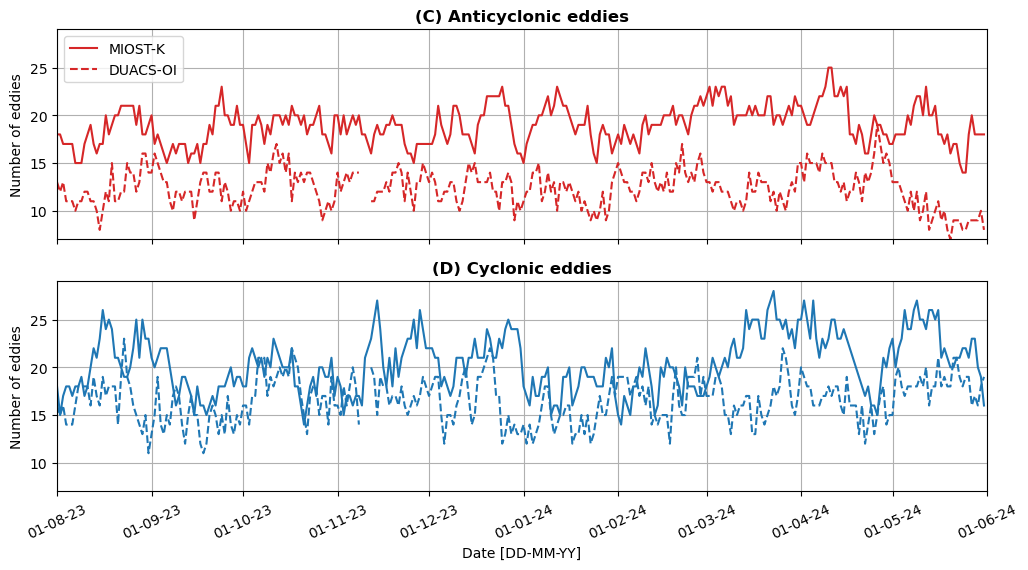

In [35]:
plt.figure(figsize=(12,6))
ax1=plt.subplot(211)
plt.plot(ndates, nb_a_m_v201, 'C3', label='MIOST-K') # anticyc.')
plt.plot(ndates, nb_a_d, '--', c='C3', label='DUACS-OI') # anticyc.')
plt.grid()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))

# Optional: Rotate date labels for better readability
plt.xticks(rotation=45)
ax1.tick_params(labelbottom=False) # Hide them

plt.ylabel("Number of eddies")
# plt.legend(loc=2)
plt.title("(C) Anticyclonic eddies", fontweight='bold')
plt.legend(loc=2)
plt.ylim([7, 29])
ax1.set_xlim(dt.datetime(2023, 8, 1), dt.datetime(2024, 6, 1))


ax1=plt.subplot(212)
plt.plot(ndates, nb_c_m_v201, 'C0', label='MIOST-K') # cyc.') #  v2.0.1
plt.plot(ndates, nb_c_d, '--', c= 'C0', label='DUACS-OI') # cyc.')

plt.grid()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))

# Optional: Rotate date labels for better readability
plt.xticks(rotation=25)

plt.xlabel("Date [DD-MM-YY]")
plt.ylabel("Number of eddies")
# plt.legend(loc=2)
plt.title("(D) Cyclonic eddies", fontweight='bold')
plt.ylim([7, 29])
ax1.set_xlim(dt.datetime(2023, 8, 1), dt.datetime(2024, 6, 1))


### Difference:

(-12.5, 12.5)

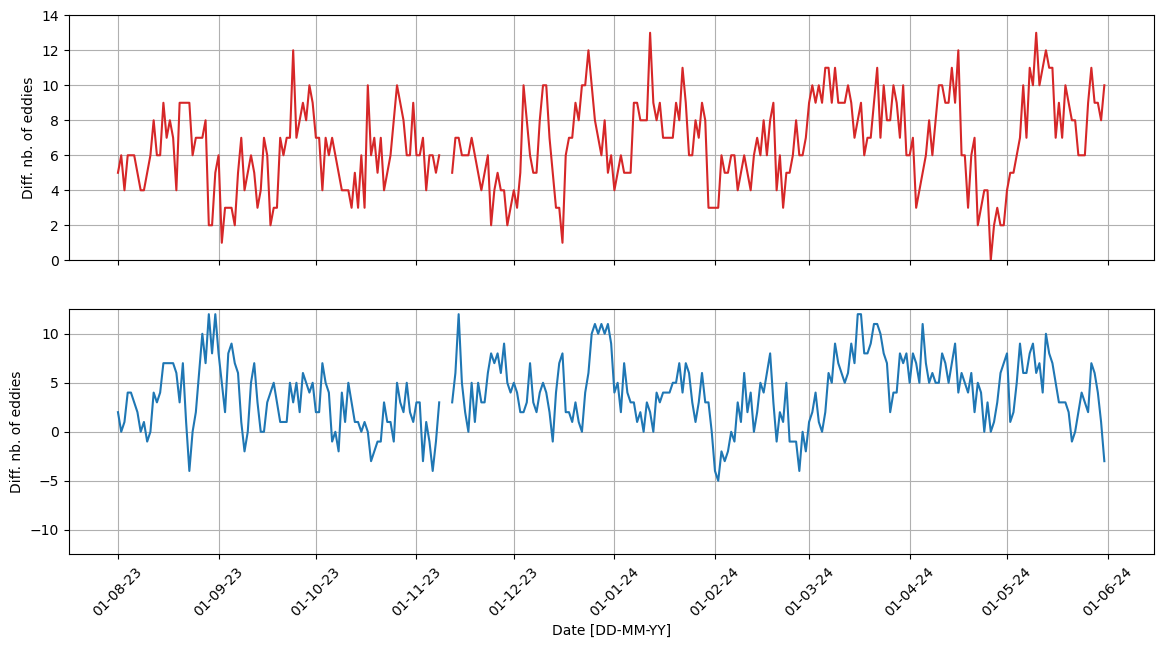

In [36]:
plt.figure(figsize=(14,7))
ax1=plt.subplot(211)
plt.plot(ndates, nb_a_m_v201 - nb_a_d, 'C3', label='MIOST-K anticyc. v2.0.1 - DUACS')
plt.grid()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))

# Optional: Rotate date labels for better readability
plt.xticks(rotation=45)
ax1.tick_params(labelbottom=False)

plt.ylabel("Diff. nb. of eddies")
# plt.legend()
plt.ylim([0, 14])

ax1=plt.subplot(212)
plt.plot(ndates, nb_c_m_v201 - nb_c_d, 'C0', label='MIOST-K cyc. v2.0.1 - DUACS')

plt.grid()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))

# Optional: Rotate date labels for better readability
plt.xticks(rotation=45)

plt.xlabel("Date [DD-MM-YY]")
plt.ylabel("Diff. nb. of eddies")
# plt.legend()
plt.ylim([-12.5, 12.5])

# Stats.:

In [37]:
print('Mean: ', f"{np.mean(nb_a_m_v201):.1f}")
print('STD: ', f"{np.std(nb_a_m_v201):.1f}")
print('Min: ', f"{np.nanmin(nb_a_m_v201):.1f}")
print('Max: ', f"{np.nanmax(nb_a_m_v201):.1f}")
print('Range: ', f"{np.nanmax(nb_a_m_v201)-np.nanmin(nb_a_m_v201):.1f}")

Mean:  19.0
STD:  2.0
Min:  14.0
Max:  25.0
Range:  11.0


In [38]:
print('Mean: ', f"{np.nanmean(nb_a_d):.1f}")
print('STD: ', f"{np.nanstd(nb_a_d):.1f}")
print('Min: ', f"{np.nanmin(nb_a_d):.1f}")
print('Max: ', f"{np.nanmax(nb_a_d):.1f}")
print('Range: ', f"{np.nanmax(nb_a_d)-np.nanmin(nb_a_d):.1f}")

Mean:  12.4
STD:  1.9
Min:  7.0
Max:  19.0
Range:  12.0


In [39]:
print('Mean: ', f"{np.mean(nb_c_m_v201):.1f}")
print('STD: ', f"{np.std(nb_c_m_v201):.1f}")
print('Min: ', f"{np.nanmin(nb_c_m_v201):.1f}")
print('Max: ', f"{np.nanmax(nb_c_m_v201):.1f}")
print('Range: ', f"{np.nanmax(nb_c_m_v201)-np.nanmin(nb_c_m_v201):.1f}")

Mean:  20.4
STD:  3.0
Min:  14.0
Max:  28.0
Range:  14.0


In [40]:
print('Mean: ', f"{np.nanmean(nb_c_d):.1f}")
print('STD: ', f"{np.nanstd(nb_c_d):.1f}")
print('Min: ', f"{np.nanmin(nb_c_d):.1f}")
print('Max: ', f"{np.nanmax(nb_c_d):.1f}")
print('Range: ', f"{np.nanmax(nb_c_d)-np.nanmin(nb_c_d):.1f}")

Mean:  16.6
STD:  2.4
Min:  11.0
Max:  23.0
Range:  12.0


In [46]:
print('Mean diff. (M-D): ', f"{np.nanmean(nb_a_m_v201-nb_a_d):.1f}")

Mean diff. (M-D):  6.6


In [47]:
print('Mean diff. (M-D): ', f"{np.nanmean(nb_c_m_v201-nb_c_d):.1f}")

Mean diff. (M-D):  3.8


# Correlation between the 2 timeseries:

In [43]:
np.corrcoef(nb_c_m_v201, nb_c_d)[0, 1]

nan

In [44]:
np.corrcoef(nb_c_m_v201, nb_c_d)

array([[ 1., nan],
       [nan, nan]])

In [45]:
nb_c_m_v201.corr(nb_c_d)

AttributeError: 'numpy.ndarray' object has no attribute 'corr'

In [ ]:
nb_c_m_v201.shape

(305,)

In [ ]:
nb_c_d.shape

(305,)

In [74]:
# Example
ts1 = nb_a_m_v201
ts2 = nb_a_d

# Keep only valid values
mask = ~np.isnan(ts1) & ~np.isnan(ts2)

corr_a = np.corrcoef(ts1[mask], ts2[mask])[0, 1]

print(f"Correlation: {corr_a:.3f}")

Correlation: 0.238


In [75]:
# Example
ts1 = nb_c_m_v201
ts2 = nb_c_d

# Keep only valid values
mask = ~np.isnan(ts1) & ~np.isnan(ts2)

corr_c = np.corrcoef(ts1[mask], ts2[mask])[0, 1]

print(f"Correlation: {corr_c:.3f}")

Correlation: 0.203


# Numpy correlation explanation:

np.corrcoef() uses the Pearson correlation coefficient.

Mathematically:

$r = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}
\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}$

It measures the linear relationship between two variables:

r = 1 → perfect positive linear relationship
r = -1 → perfect negative linear relationship
r = 0 → no linear relationship

Numpy calculates: 
```
cov(x, y) / (std(x) * std(y))
```

https://chatgpt.com/c/6a0b342f-4174-8395-a069-0867422e31fb